## Visualizing tweets and Logistic Regression Model

In [2]:
# 1. plot tweets in a scatter plot using their positive and negative sums
# 2. plot the output of the logistic regression model in the same plot as a solid line

In [4]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 53.5 MB/s  0:00:00m0:00:01


In [5]:
import matplotlib.pyplot as plt
from utils import process_tweet, build_freqs
import numpy as np

import nltk
from nltk.corpus import twitter_samples
from os import getcwd
import pandas as pd

nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/koushalsmodi/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

## Load the NLTK dataset

In [9]:
# all positive and negative samples; concatenate into a single list; and labels
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

tweets = all_positive_tweets + all_negative_tweets
# Make this a column vector (2D)
# stack it vertically
labels = np.append(np.ones((len(all_positive_tweets), 1)), np.zeros((len(all_negative_tweets), 1)), axis = 0)

# split the data into 2 pieces; 1 for training and 1 for testing
train_pos = all_positive_tweets[:4000]
train_neg = all_negative_tweets[:4000]

train_x = train_pos + train_neg

print("Number of Tweets:", len(train_x))

Number of Tweets: 8000


## Load the extracted features

In [15]:
data = pd.read_csv('/Users/koushalsmodi/Desktop/MachineLearning/MachineLearningProjects/NLP/data/logistic_features.csv')
data.head()

,bias,positive,negative,sentiment
0,1.0,3020.0,61.0,1.0
1,1.0,3573.0,444.0,1.0
2,1.0,3005.0,115.0,1.0
3,1.0,2862.0,4.0,1.0
4,1.0,3119.0,225.0,1.0


In [17]:
# getting only the numerical values of the dataframe
X = data[['bias', 'positive', 'negative']].values
Y = data['sentiment'].values # corresponding labels (sentiment)

print(X.shape)
print()
print(X)

(8000, 3)

[[1.000e+00 3.020e+03 6.100e+01]
 [1.000e+00 3.573e+03 4.440e+02]
 [1.000e+00 3.005e+03 1.150e+02]
 ...
 [1.000e+00 1.440e+02 7.830e+02]
 [1.000e+00 2.050e+02 3.890e+03]
 [1.000e+00 1.890e+02 3.974e+03]]


## Load a pretrained Logistic Regression Model

In [18]:
theta = [6.03518871e-08, 5.38184972e-04, -5.58300168e-04]

## Plot the samples in a scatter plot

Text(0, 0.5, 'Negative')

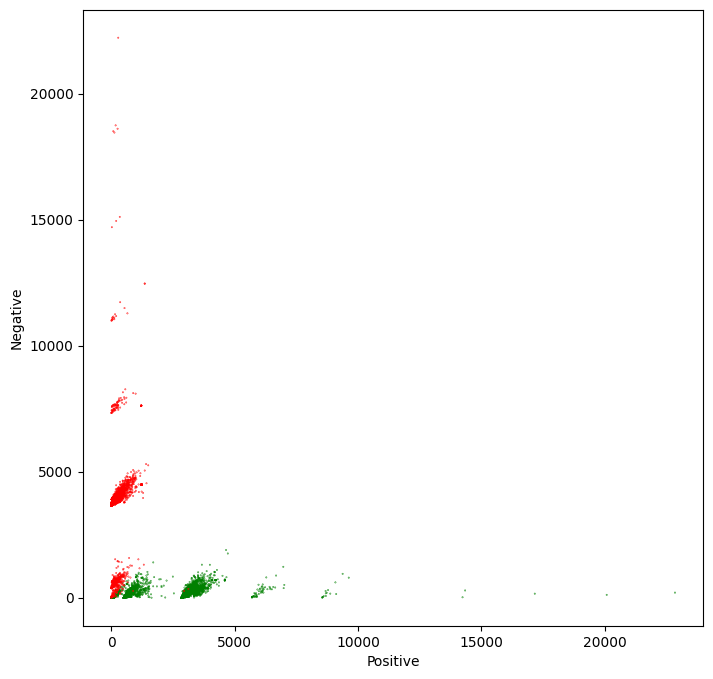

In [ ]:
# positive tweets are green
# negative tweets are red

fig, ax = plt.subplots(figsize = (8,8))

colors = ['red', 'green']

ax.scatter(X[:,1], X[:,2], c = [colors[int(k)] for k in Y], s = .1)
plt.xlabel("Positive")
plt.ylabel("Negative")

# almost perfect separation between positive and negative tweets

## Plot the model alongside the data